In [1]:
# Cell 1 — Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.0f}".format)

In [2]:
# Cell 2 — Load data
df_all = pd.read_csv("../data/raw/uganda_food_prices_sample.csv", parse_dates=["date"])
print(df_all.shape)
df_all.head()



FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/uganda_food_prices_sample.csv'

NameError: name 'df_all' is not defined

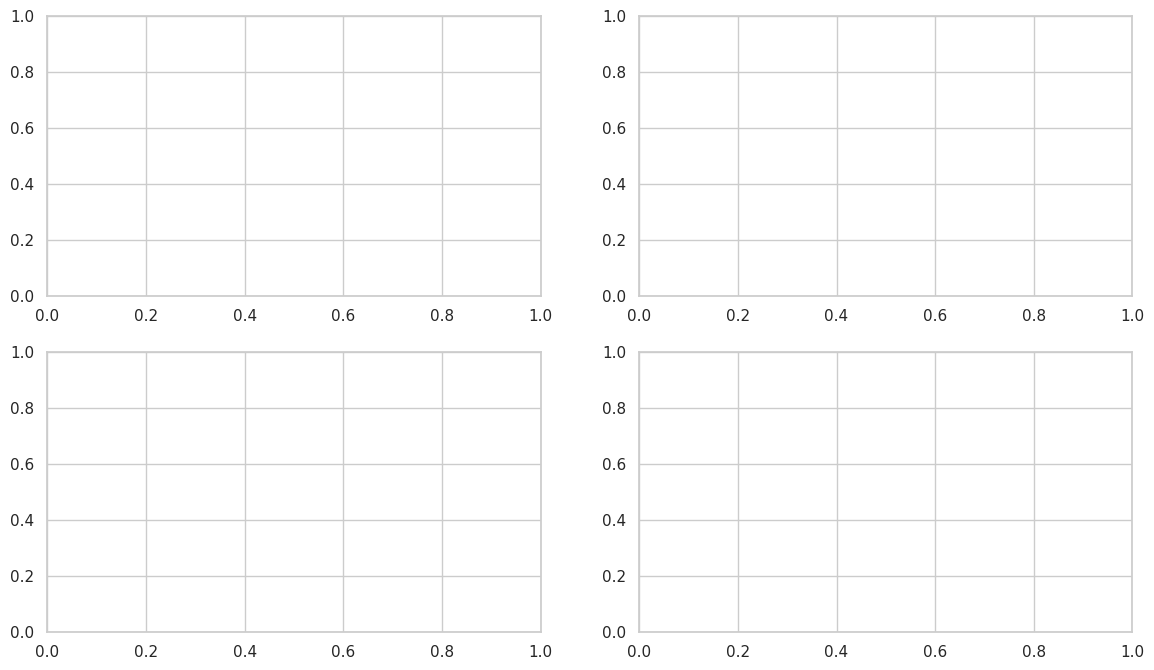

In [3]:
# Cell 3 — Overview
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (commodity, grp) in zip(axes.flat, df_all.groupby("commodity")):
    for market, sub in grp.groupby("market"):
        ax.plot(sub["date"], sub["price"], alpha=0.5, linewidth=0.8, label=market)
    ax.set_title(commodity)
    ax.set_ylabel("UGX/kg")
    ax.legend(fontsize=7)
plt.suptitle("Uganda Crop Prices by Market", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Cell 4 — Pick one series to model
commodity = "Maize"
market = "Kampala"

df = df_all[
    (df_all["commodity"] == commodity) & (df_all["market"] == market)
][["date", "price"]].dropna().rename(columns={"date": "ds", "price": "y"})
df = df.sort_values("ds").reset_index(drop=True)
print(f"{len(df)} weeks of data: {df['ds'].min().date()} to {df['ds'].max().date()}")



In [4]:
# Cell 5 — Train/test split
split = int(len(df) * 0.8)
train, test = df[:split], df[split:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
)
model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
model.fit(train)



NameError: name 'df' is not defined

In [5]:
# Cell 6 — Evaluate
future = model.make_future_dataframe(periods=len(test), freq="W")
forecast = model.predict(future)
preds = forecast.tail(len(test))["yhat"].values

mae = mean_absolute_error(test["y"], preds)
mape = mean_absolute_percentage_error(test["y"], preds)
print(f"MAE:  {mae:,.0f} UGX/kg")
print(f"MAPE: {mape:.2%}")



NameError: name 'model' is not defined

NameError: name 'train' is not defined

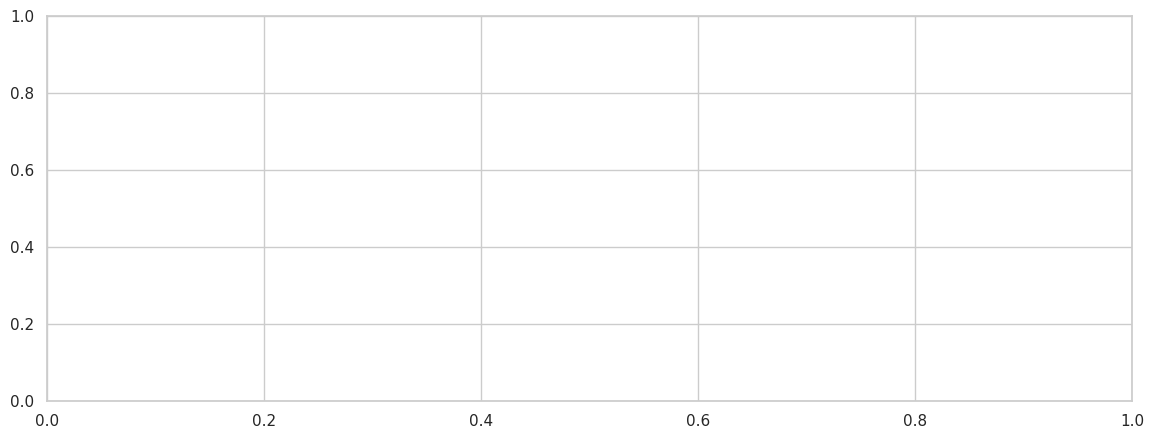

In [6]:
# Cell 7 — Plot results
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train["ds"], train["y"], label="Train", color="steelblue")
ax.plot(test["ds"], test["y"], label="Actual", color="green")
ax.plot(forecast.tail(len(test))["ds"], preds, label="Forecast", color="red", linestyle="--")
ax.fill_between(
    forecast.tail(len(test))["ds"],
    forecast.tail(len(test))["yhat_lower"],
    forecast.tail(len(test))["yhat_upper"],
    alpha=0.2, color="red", label="Confidence interval"
)
ax.set_title(f"{commodity} @ {market} — Prophet Forecast")
ax.set_ylabel("UGX/kg")
ax.legend()
plt.tight_layout()
plt.show()



In [7]:
# Cell 8 — Future forecast (next 12 weeks)
model.fit(df)
future_12 = model.make_future_dataframe(periods=12, freq="W")
fc_12 = model.predict(future_12).tail(12)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
fc_12.columns = ["Date", "Price (UGX/kg)", "Lower", "Upper"]
fc_12["Date"] = fc_12["Date"].dt.strftime("%Y-%m-%d")
fc_12.set_index("Date")

NameError: name 'model' is not defined